
# <span style="color:rgb(213,80,0)">Alkaline Membrane Electrolyser Impedance computation</span>

## Setup model

In [1]:
jsonstruct_material = parseBattmoJson('Electrolyser/Parameters/alkalineElectrolyser.json');
jsonstruct_geometry = parseBattmoJson('Electrolyser/Parameters/electrolysergeometry1d.json');

jsonstruct = mergeJsonStructs({jsonstruct_material, ...
                               jsonstruct_geometry});

inputparams = ElectrolyserInputParams(jsonstruct);
inputparams = setupElectrolyserGridFromJson(inputparams, jsonstruct);

## Setup Impedance solver

We use a given current. The steady state is computed at setup.


In [2]:
options = [];
options.stateInitialization.initializationSetup = 'given current';
options.stateInitialization.computeSteadyState  = true;
options.stateInitialization.I = -3*ampere/(centi*meter)^2;

impsolv = ElectrolyserImpedanceSolver(inputparams, options);

## Compute the impedance for a range of frequencies

In [3]:
omegas = linspace(-4, 2, 30);
omegas = 10.^omegas;
Z = impsolv.computeImpedance(omegas);

## Plots of the results


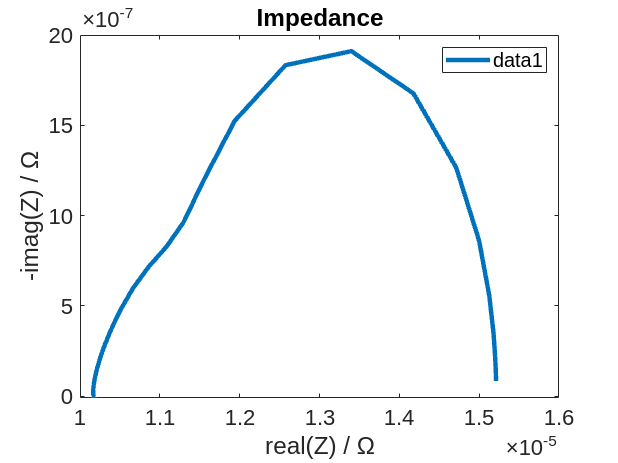

In [4]:
set(0, 'defaultlinelinewidth', 3);
figure
plot(real(Z), -imag(Z));
xlabel('real(Z) / Ω')
ylabel('-imag(Z) / Ω')
legend show
title('Impedance')